# Exercise 3: Fitting

## Analysis of Exponential Decay Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(42)
t = np.linspace(0, 2, 15)
tau_true = 1.5

sigma = 0.05
data = np.exp(-t / tau_true) + np.random.normal(0, sigma, size=len(t))
y_errors = np.full_like(data, sigma)

np.savetxt("data_ex1.txt", np.column_stack((t, data)), header="t data")

You are given a dataset representing exponential decay with added noise. The fraction of remaining particles follows the equation:  


$$y = e^{t/\tau}$$


where:  
- $ \tau $ is the decay constant,  
- $ t $ represents time,  
- measurement uncertainty is estimated to be $ \sigma = 0.1 $ for all times.  

**Tasks**  

**1. Compute the Chi-Squared Statistic**  
- Evaluate $ \chi^2 $ for $ \tau $ values between 1 and 2.  
- Identify the best-fit $ \tau $ by finding the minimum $ \chi^2 $.  

**2. Estimate Uncertainty**  
- Use the $ \Delta \chi^2 $ method to determine the confidence interval for $ \tau $.  

**3. Visualize the Data and Best Fit**  
- Plot the given data with error bars.  
- Overlay the best-fit exponential decay curve.  

**4. Graphical Representation of $ \chi^2 $**  
- Plot $ \chi^2 $ as a function of $ \tau $.  
- Highlight the $ 1\sigma $ confidence regions based on $ \Delta \chi^2 $.  

**5. Goodness of fit**
- Looking at the mimimum $\chi^2$, do you think the uncertainty estimation is realistic?

In [2]:
t, data = np.loadtxt("data_ex1.txt", unpack=True)
y_errors = np.full_like(data, 0.1)

Miminum chi2: 3.423


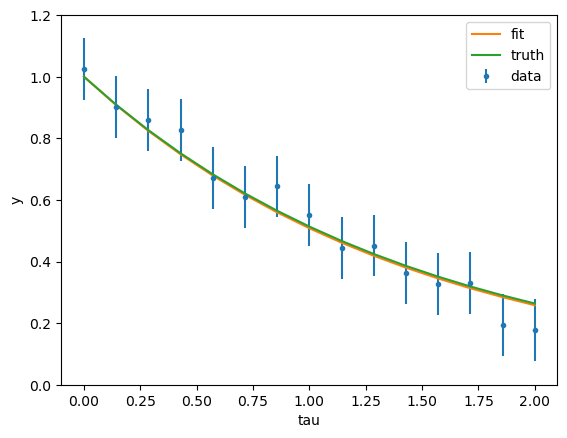

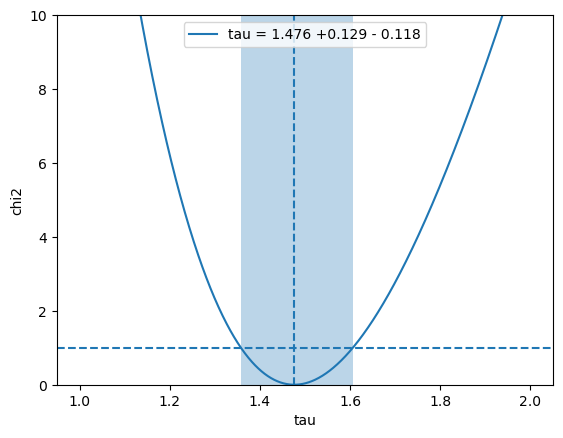

In [3]:
def model(t, tau):
    return np.exp(-t / tau)

def chi2(tau, t, y, y_err):
    return np.sum(((y - model(t, tau)) / y_err) ** 2)

tau = np.linspace(1, 2, 1000)
chi2_values = np.array([chi2(x, t, data, y_errors) for x in tau])
print(f"Miminum chi2: {chi2_values.min():.3f}")
chi2_values -= chi2_values.min()

tau_best = tau[np.argmin(chi2_values)]
tau_lower, tau_upper = tau[chi2_values <= 1][[0, -1]]


plt.figure()
plt.errorbar(t, data, yerr=y_errors, fmt=".", label="data")
plt.plot(t, model(t, tau_best), label="fit")
plt.plot(t, model(t, tau_true), label="truth")
plt.legend()
plt.xlabel("tau")
plt.ylabel("y")
plt.ylim(0,1.2)

plt.figure()
plt.plot(tau, chi2_values, label=f"tau = {tau_best:.3f} +{tau_upper-tau_best:.3f} - {tau_best-tau_lower:.3f}")
plt.axvline(tau_best, ls="--")
plt.axvspan(tau_lower, tau_upper, alpha=0.3)
plt.axhline(1, ls="--")
plt.xlabel("tau")
plt.ylabel("chi2")
plt.ylim(0,10)
plt.legend()

Answer to 5.: The minimum chi2 is much smaller than the number of degrees of freedom. The uncertainties might be over-estimated.

In the lecture, we learned how to compute the best estimate of a parameter analytically in the case of a linear function. Now, compute the best estimate for $\tau$, including the uncertainty, in a similar way. 

Do you get "compatible" results ?

**Hint**: You may want to use a coordinate transformation.

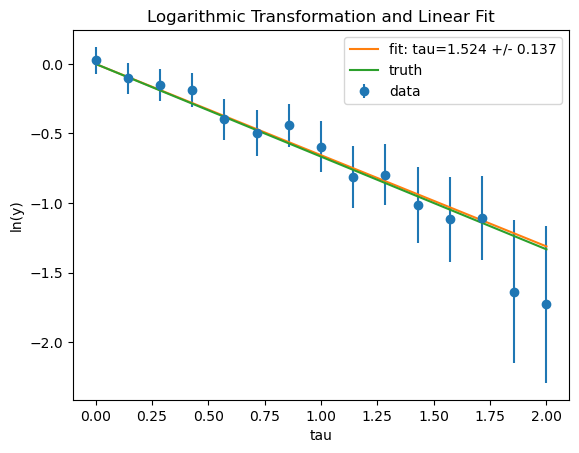

In [4]:
y_log = np.log(data)
y_log_errors = y_errors / data

weighted_sum_yt = np.sum(t * y_log / (y_log_errors**2))
weighted_sum_tt = np.sum(t**2 / (y_log_errors**2))

slope = weighted_sum_yt / weighted_sum_tt
slope_uncertainty = np.sqrt(1 / weighted_sum_tt)

tau_fit = -1 / slope
tau_fit_error = slope_uncertainty / slope**2

plt.errorbar(t, y_log, yerr=y_log_errors, fmt='o', label="data")
plt.plot(t, slope * t, label=f"fit: tau={tau_fit:.3f} +/- {tau_fit_error:.3f}")
plt.plot(t, -t/tau_true, label="truth")
plt.xlabel("tau")
plt.ylabel("ln(y)")
plt.title("Logarithmic Transformation and Linear Fit")
plt.legend()
plt.show()


## Polynomial Fit with Parameter Uncertainty

You are given data that was generated using a polynomial of degree 5. Therefore, you have 6 free parameters (the 6 coefficients). Your task is to perform a fit to obtain these parameters and their covariances.

**Steps:**
1. Fit a polynomial to the data and determine the parameters.
2. Calculate the uncertainties for each parameter.
3. **Bonus**: Instead of just showing the 1D uncertainties for each parameter, visualize the correlations between these uncertainties.

You can use an optimizer from `scipy` to perform the fit and "TriangleChain" for the last point.

In [5]:
np.random.seed(42)

def true_function(x, a0, a1, a2, a3, a4, a5):
    return a0 + a1*x + a2*x**2 + a3*x**3 + a4*x**4 + a5*x**5
n_samples = 15
x = np.linspace(-1, 1, n_samples)
true_params = np.array([2.0, -1.5, 3.0, 0.5, -2.0, 1.0])
y_data = true_function(x, *true_params) + np.random.normal(0, 0.2, n_samples)

np.savetxt("data_ex2.txt", np.column_stack((x, y_data)), header="x data")

In [6]:
x, data = np.loadtxt("data_ex2.txt", unpack=True)

Fitted parameters:
a0 = 2.086 ± 0.081
a1 = -1.671 ± 0.317
a2 = 2.831 ± 0.459
a3 = 0.608 ± 1.138
a4 = -2.075 ± 0.457
a5 = 0.838 ± 0.900


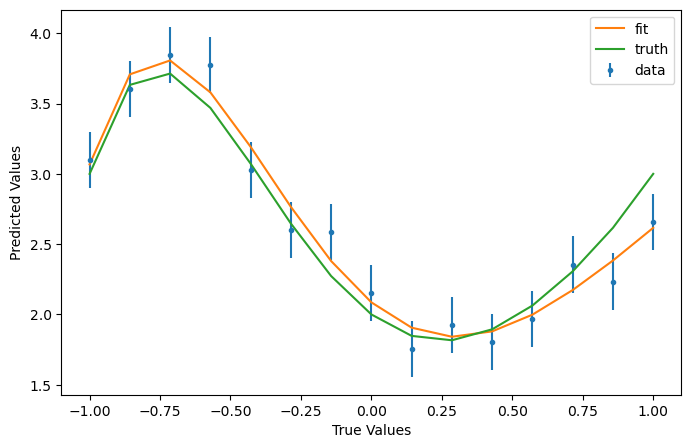

25-03-10 13:56:25 TriangleCh INF   Computing bestfits and levels 


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

/Users/silvanfischbacher/miniforge3/envs/galsbi-cpvn/lib/python3.12/site-packages/scipy/signal/windows/_windows.py:1379: RuntimeWarning: divide by zero encountered in divide
  w = np.exp(-n ** 2 / sig2)
/Users/silvanfischbacher/miniforge3/envs/galsbi-cpvn/lib/python3.12/site-packages/scipy/signal/windows/_windows.py:1379: RuntimeWarning: invalid value encountered in divide
  w = np.exp(-n ** 2 / sig2)
/Users/silvanfischbacher/repos/trianglechain/src/trianglechain/utils_plots.py:409: RuntimeWarning: invalid value encountered in divide
  return y / np.trapz(y, x)
/Users/silvanfischbacher/repos/trianglechain/src/trianglechain/utils_plots.py:664: RuntimeWarning: All-NaN slice encountered
  min_x = np.nanmin(x)
/Users/silvanfischbacher/repos/trianglechain/src/trianglechain/utils_plots.py:665: RuntimeWarning: All-NaN slice encountered
  max_x = np.nanmax(x)


  0%|          | 0/15 [00:00<?, ?it/s]

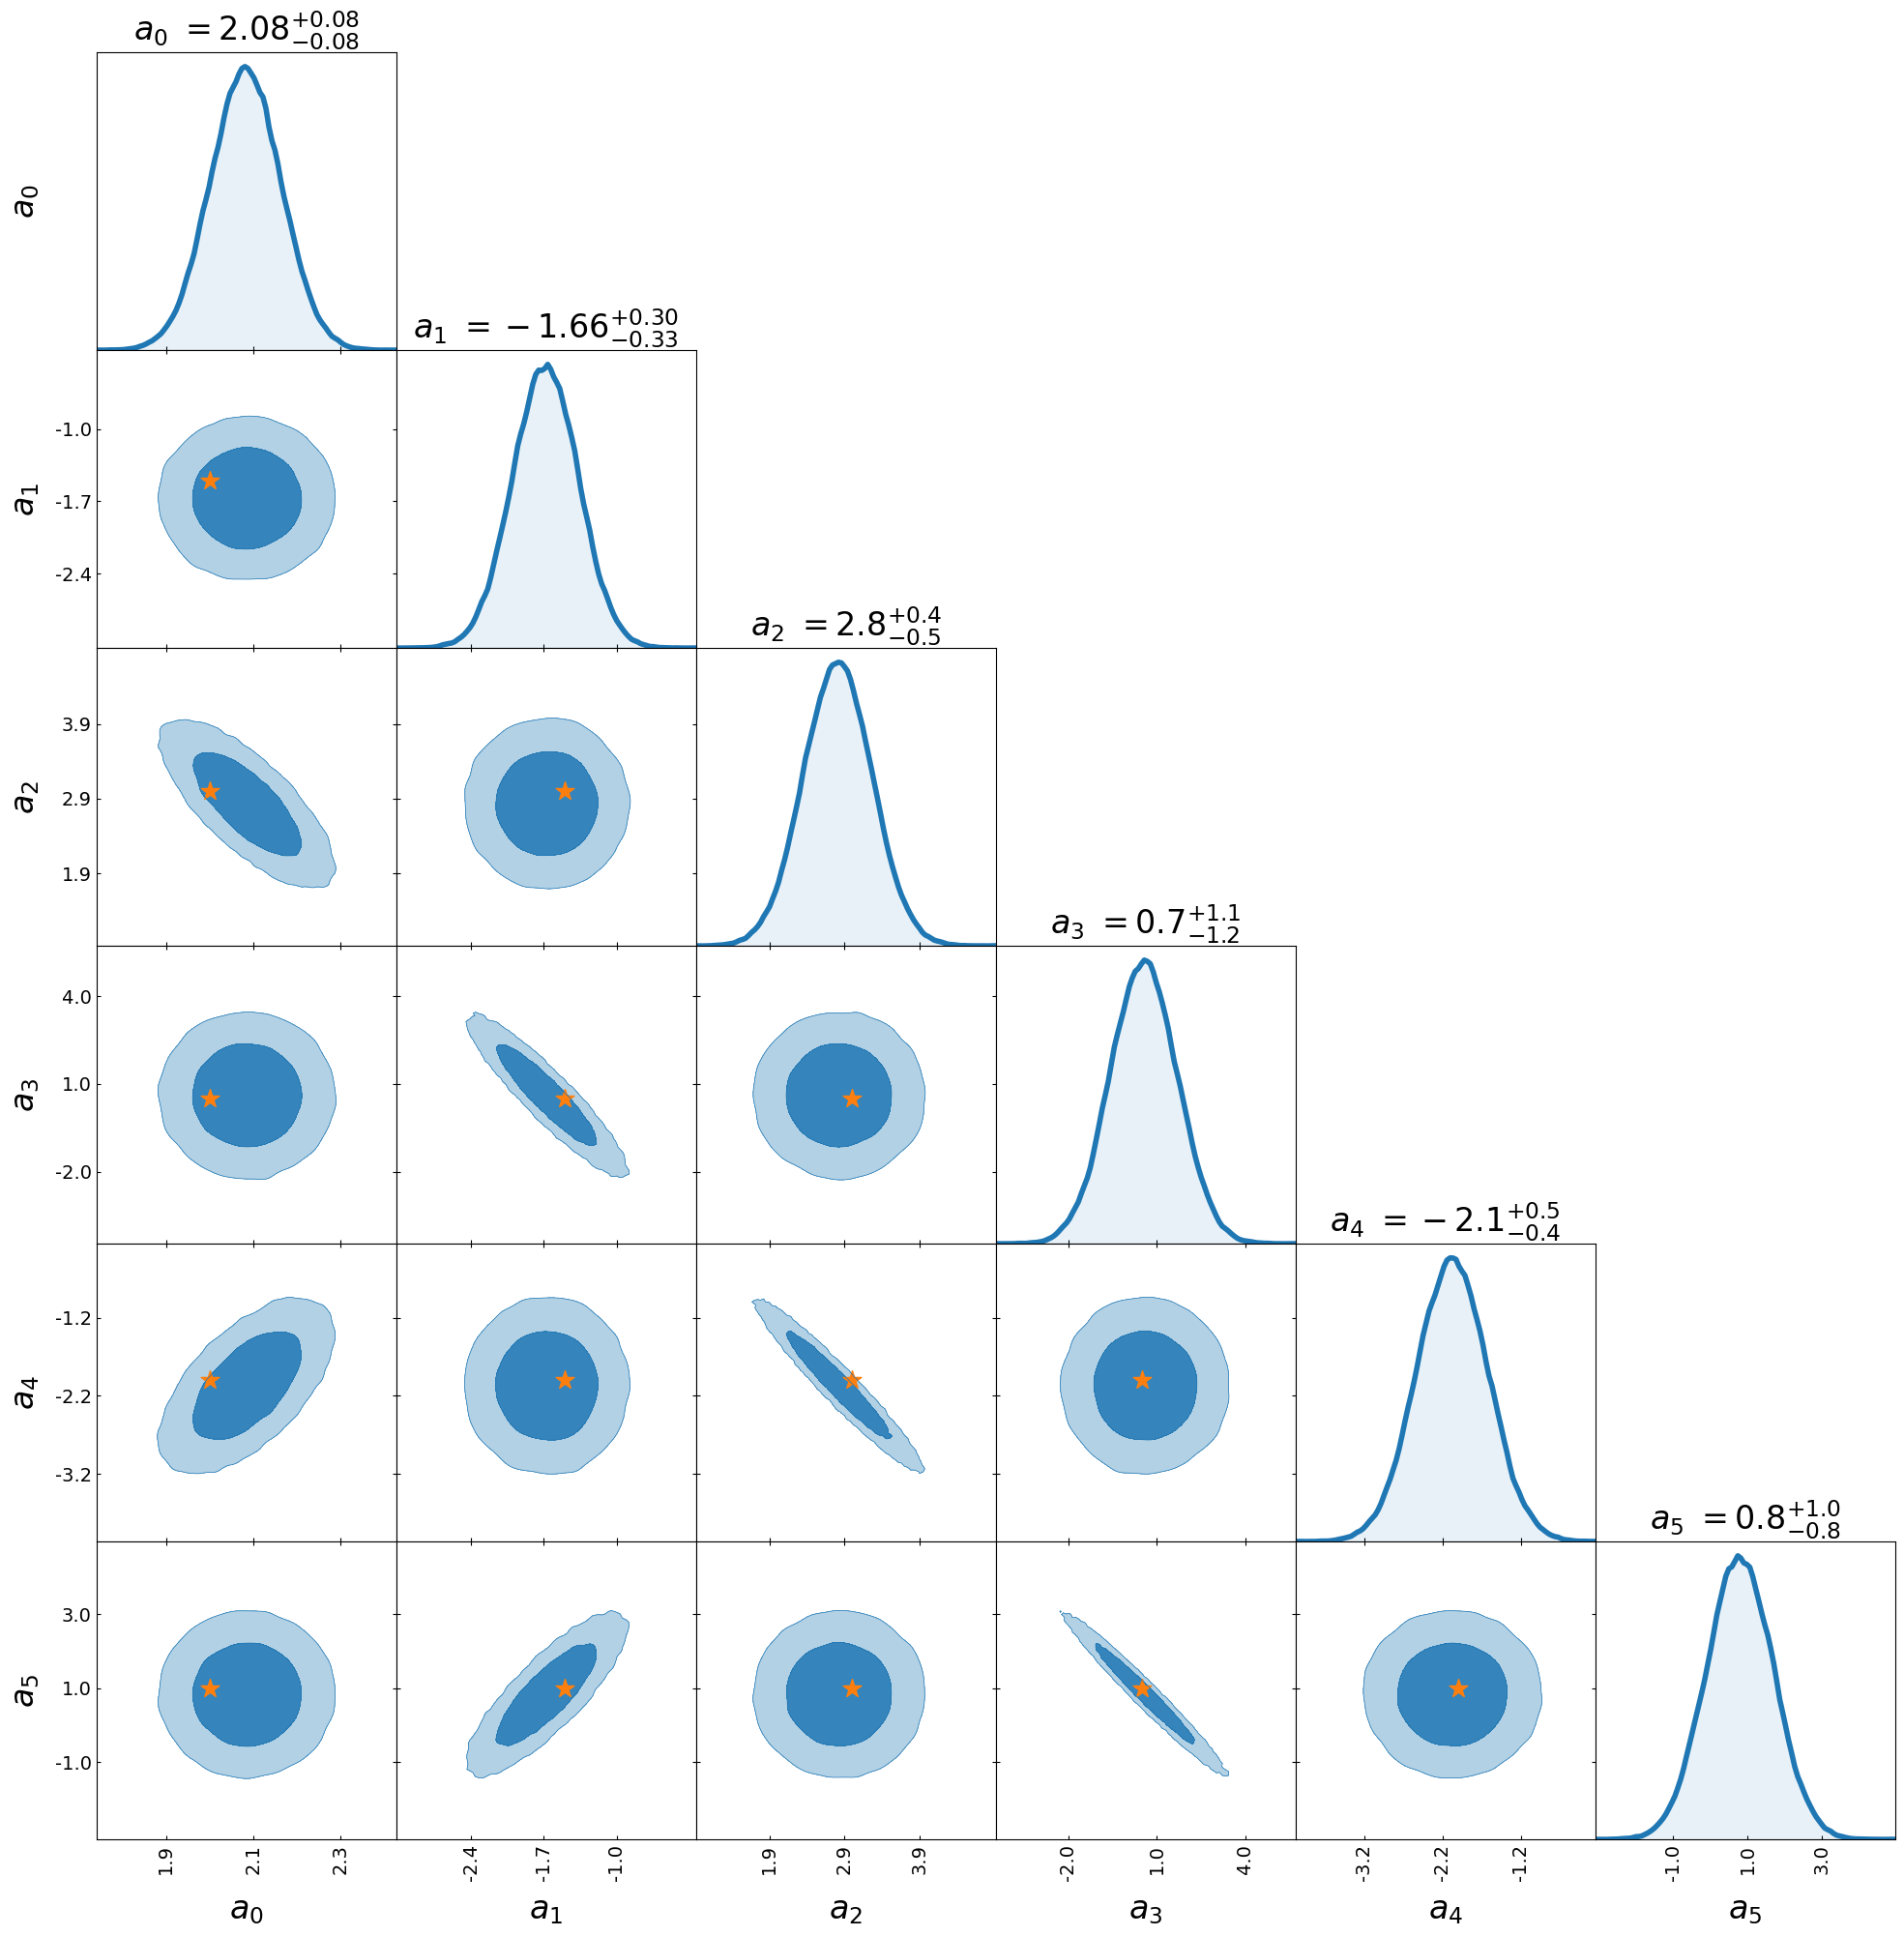

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from trianglechain import TriangleChain

def fit_function(x, a0, a1, a2, a3, a4, a5):
    return true_function(x, a0, a1, a2, a3, a4, a5)

initial_guess = np.ones(6)
params_opt, params_cov = curve_fit(fit_function, x, y_data, p0=initial_guess)

print("Fitted parameters:")
for i, param in enumerate(params_opt):
    print(f"a{i} = {param:.3f} ± {np.sqrt(params_cov[i, i]):.3f}")

# Plot actual vs predicted
y_pred = fit_function(x, *params_opt)
plt.figure(figsize=(8, 5))
plt.errorbar(x, y_data, yerr=0.2, fmt=".", label="data")
plt.plot(x, y_pred, label="fit")
plt.plot(x, true_function(x, *true_params), label="truth")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()

samples = np.random.multivariate_normal(params_opt, params_cov, size=int(1e5))

scatter_kwargs = {"s": 200, "marker": "*"}
tri = TriangleChain(names=[f"$a_{i}$" for i in range(6)], fill=True, scatter_kwargs=scatter_kwargs)
tri.contour_cl(samples, show_values=True);
tri.scatter(np.atleast_2d(true_params));

## Goodness of fit

In [8]:
np.random.seed(42)
x = np.linspace(-5, 5, 50)
y_true = 0.4*x**2 + 2*x + 5
noise = np.random.normal(0, 5, size=y_true.shape)
y_observed = y_true + noise
np.savetxt("data_ex3.txt", np.column_stack((x, y_observed)), header="x data")

You are given datasets $x$ and $y$ that follow a polynomial relationship, with the uncertainty in $y$ equal to 5. Fit both a first-degree (linear) and a second-degree (quadratic) polynomial to the data. Compute the reduced chi-squared and the p-value for each model. Determine which model provides a better fit based on these statistical measures.

What would happen to the p value if you further increase the degrees of the polynomial?

In [9]:
x, y = np.loadtxt("data_ex3.txt", unpack=True)
y_err = np.ones_like(y) * 5

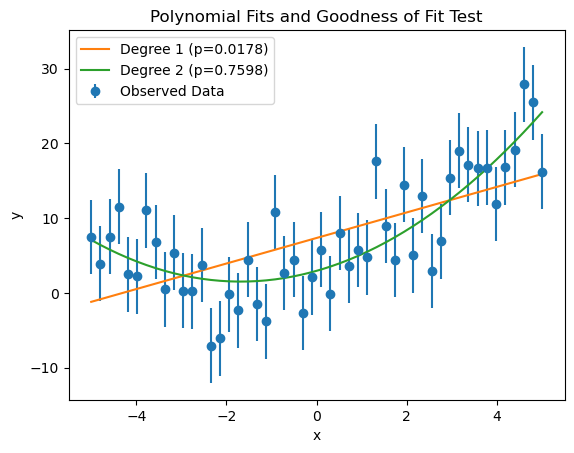

Degree 1: reduced Chi-Square = 1.445, p-value = 0.018
Degree 2: reduced Chi-Square = 0.814, p-value = 0.760


In [10]:
# Solution
from scipy import stats

def chi_square_test(x, y_observed, degree, noise_std=5):
    coeffs = np.polyfit(x, y_observed, degree)
    poly_func = np.poly1d(coeffs)
    y_expected = poly_func(x)
    
    chi2_stat = np.sum(((y_observed - y_expected) ** 2) / noise_std**2)
    df = len(x) - (degree + 1)
    p_value = 1 - stats.chi2.cdf(chi2_stat, df)
    
    return chi2_stat, p_value, poly_func

degrees = [1, 2]
results = {}

plt.errorbar(x, y_observed, yerr=y_err, label="Observed Data", fmt="o")

for degree in degrees:
    chi2_stat, p_value, poly_func = chi_square_test(x, y_observed, degree)
    results[degree] = (chi2_stat, p_value)
    plt.plot(x, poly_func(x), label=f"Degree {degree} (p={p_value:.4f})")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Fits and Goodness of Fit Test")
plt.show()

n_dof = len(x) - 1
for degree, (chi2, p) in results.items():
    print(f"Degree {degree}: reduced Chi-Square = {chi2/n_dof:.3f}, p-value = {p:.3f}")

If you increase the degrees of the polynomial (add more terms to the model), the p-value would increase, approaching 1. This is because the model becomes increasingly capable of fitting the data "perfectly," even if it's just fitting the noise or irrelevant fluctuations. Therefore, the p-value might not provide meaningful guidance about which model is best, especially if overfitting occurs due to an excessive number of degrees of freedom. The reduced chi-square in this scenario would approach 0, indicating that something is wrong in the number of degrees of freedom (or the uncertainty estimation).
See later in the lectures the F-test.

## Gradient descent
Minimize the function:

$$
f(x, y) = x^2 + (y - 1)^2 + 0.1 \cdot x^4 + 0.1 \cdot y^4
$$

1. **Compute the Gradient**  
   Find the partial derivatives of the function with respect to $x$ and $y$.

2. **Implement Gradient Descent**  
   Update the parameters using:
   $$
   x_{\text{new}} = x_{\text{old}} - \alpha \cdot \frac{\partial f}{\partial x}, \quad y_{\text{new}} = y_{\text{old}} - \alpha \cdot \frac{\partial f}{\partial y}
   $$

3. **Plot the Path to the Minimum**  
   Run gradient descent with different starting points and learning rates. Plot the optimization path to the minimum for the different scenarios and plot how the step size evolves.

4. **Different function**
    Change the initial function (e.g. change $x^2$ to $x^3$) and redo Steps 1-3. Do you have to adapt the learning rate?

In [11]:
def f(x, y):
    return x**2 + (y-1)**2 + 0.1 * (x**4) + 0.1 * (y**4)

def df_dx(x, y):
    return 2 * x + 0.4 * (x**3)

def df_dy(x, y):
    return 2 * y + 0.4 * (y**3) - 2

def gradient_descent(start_x, start_y, learning_rate, num_iterations, df_dx, df_dy):
    x = start_x
    y = start_y
    history_x = [x]
    history_y = [y]
    history_f = [f(x,y)]
    
    for i in range(num_iterations):
        grad_x = df_dx(x, y)
        grad_y = df_dy(x, y)
        
        x = x - learning_rate * grad_x
        y = y - learning_rate * grad_y
        
        history_x.append(x)
        history_y.append(y)
        history_f.append(f(x, y))
    
    return history_x, history_y, history_f

Text(0, 0.5, 'step size y')

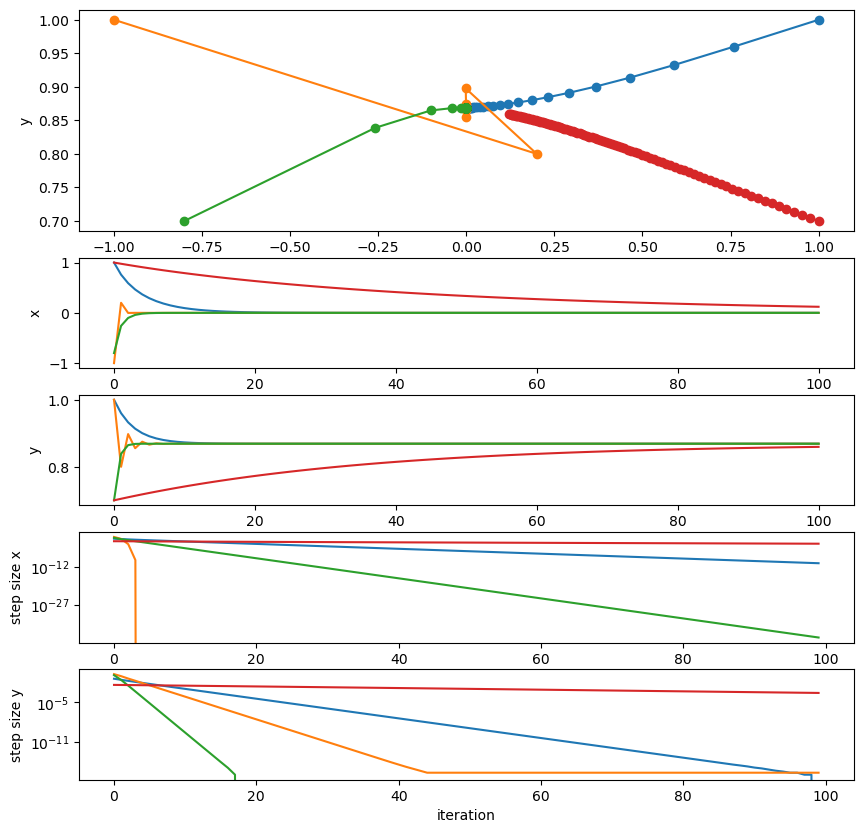

In [12]:
fig, axs = plt.subplots(5, height_ratios=(2,1,1,1,1), figsize=(10,10))
xs, ys, fs = gradient_descent(1, 1, 0.1, 100, df_dx, df_dy)
axs[0].plot(xs, ys, "-o")
axs[1].plot(xs)
axs[2].plot(ys)
axs[3].semilogy(abs(np.diff(xs)))
axs[4].semilogy(abs(np.diff(ys)))

xs, ys, fs = gradient_descent(-1, 1, 0.5, 100, df_dx, df_dy)
axs[0].plot(xs, ys, "-o")
axs[1].plot(xs)
axs[2].plot(ys)
axs[3].semilogy(abs(np.diff(xs)))
axs[4].semilogy(abs(np.diff(ys)))

xs, ys, fs = gradient_descent(-0.8, 0.7, 0.3, 100, df_dx, df_dy)
axs[0].plot(xs, ys, "-o")
axs[1].plot(xs)
axs[2].plot(ys)
axs[3].semilogy(abs(np.diff(xs)))
axs[4].semilogy(abs(np.diff(ys)))

xs, ys, fs = gradient_descent(1, 0.7, 0.01, 100, df_dx, df_dy)
axs[0].plot(xs, ys, "-o")
axs[1].plot(xs)
axs[2].plot(ys)
axs[3].semilogy(abs(np.diff(xs)))
axs[4].semilogy(abs(np.diff(ys)))


axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

axs[1].set_xlabel("iteration")
axs[2].set_xlabel("iteration")
axs[3].set_xlabel("iteration")
axs[4].set_xlabel("iteration")
axs[1].set_ylabel("x")
axs[2].set_ylabel("y")
axs[3].set_ylabel("step size x")
axs[4].set_ylabel("step size y")

Text(0, 0.5, 'step size y')

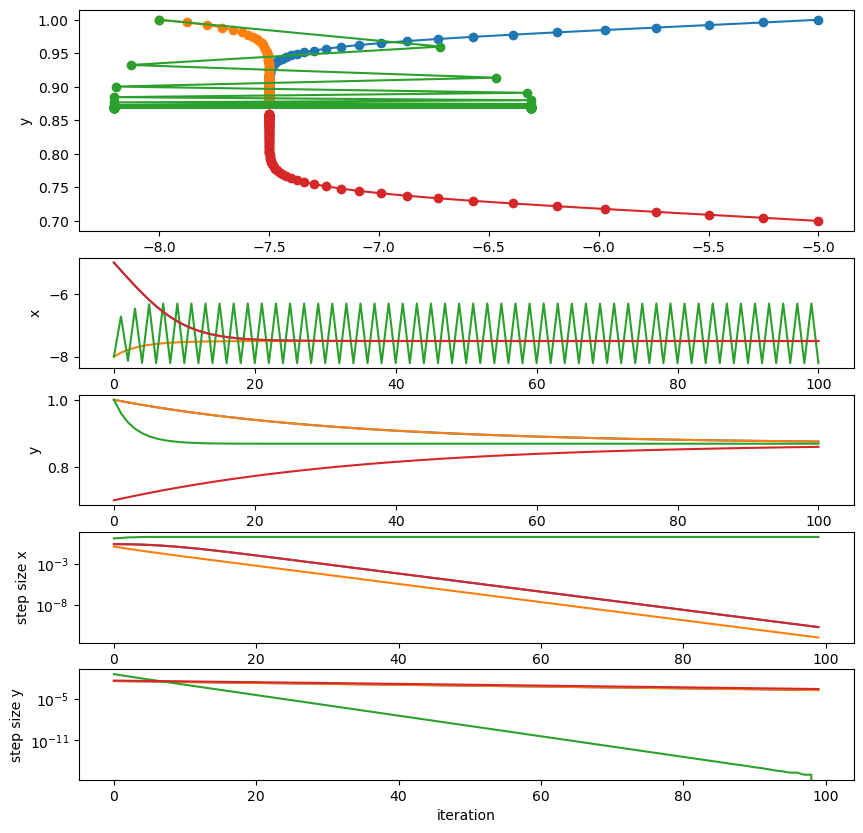

In [13]:
def f2(x, y):
    return x**3 + (y-1)**2 + 0.1 * (x**4) + 0.1 * (y**4)

def df2_dx(x, y):
    return 3 * x**2 + 0.4 * (x**3)

def df2_dy(x, y):
    return 2 * y + 0.4 * (y**3) - 2

fig, axs = plt.subplots(5, height_ratios=(2,1,1,1,1), figsize=(10,10))
xs, ys, fs = gradient_descent(-5, 1, 0.01, 100, df2_dx, df2_dy)
axs[0].plot(xs, ys, "-o")
axs[1].plot(xs)
axs[2].plot(ys)
axs[3].semilogy(abs(np.diff(xs)))
axs[4].semilogy(abs(np.diff(ys)))

xs, ys, fs = gradient_descent(-8, 1, 0.01, 100, df2_dx, df2_dy)
axs[0].plot(xs, ys, "-o")
axs[1].plot(xs)
axs[2].plot(ys)
axs[3].semilogy(abs(np.diff(xs)))
axs[4].semilogy(abs(np.diff(ys)))

xs, ys, fs = gradient_descent(-8, 1, 0.1, 100, df2_dx, df2_dy)
axs[0].plot(xs, ys, "-o")
axs[1].plot(xs)
axs[2].plot(ys)
axs[3].semilogy(abs(np.diff(xs)))
axs[4].semilogy(abs(np.diff(ys)))

xs, ys, fs = gradient_descent(-5, 0.7, 0.01, 100, df2_dx, df2_dy)
axs[0].plot(xs, ys, "-o")
axs[1].plot(xs)
axs[2].plot(ys)
axs[3].semilogy(abs(np.diff(xs)))
axs[4].semilogy(abs(np.diff(ys)))


axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

axs[1].set_xlabel("iteration")
axs[2].set_xlabel("iteration")
axs[3].set_xlabel("iteration")
axs[4].set_xlabel("iteration")
axs[1].set_ylabel("x")
axs[2].set_ylabel("y")
axs[3].set_ylabel("step size x")
axs[4].set_ylabel("step size y")

The learning rate in the 3rd case (green) is too large and the x solution does not converge but oscillates. For the same starting value but smaller learning rate (orange), gradient descent converges smoothly.